# 11: Attendance Model(CatBoost on Linear Residuals)

This notebook used to fit a single `CatBoostRegressor` directly on
`log_attendance`, using `metro_size` (60-min catchment population) as one of its features. 
But CatBoost (like any tree model) cannot extrapolate past the range of values it was
trained on, and Etihad Park's real catchment population is 2.2x the largest value ever seen in
training. Verified in the session that produced this rewrite: capping `metro_size` at the
training max vs. feeding it the real value produced the *identical* prediction.

**Fix: a residual two-stage model**

1. `10_attendance_model.ipynb` fits `log_attendance ~ log_metro_size` (linear, clustered SE by
   team) and publishes its coefficient to `output/attendance_linear_model_coefficients.csv`.
2. This notebook loads that coefficient, computes `residual = log_attendance - linear_pred` for
   every row, and trains CatBoost on the **residual**, using every other original feature
   (`table_rank`, `opponent_table_rank`, `days_since_last_home_game`, `day_of_week`, `year`,
   `venue_name`, `home_team`, `away_team`, `stadium_capacity`, `dedicated_soccer_facility`,
   `shared_with_other_league`, `team_venue_tenure`, `team_league_tenure`). **`metro_size` is
   excluded from CatBoost's feature list entirely**, so the tree stage cannot re-learn (and
   re-flatten) the accessibility effect through the back door.
3. Final prediction = `exp(linear_pred + catboost_residual_pred)`. For Etihad Park, the linear
   stage extrapolates honestly using the real metro_size (no capping needed) and CatBoost only
   ever sees in-range features.

CatBoost trains on 950 rows now, not 1132 because of a few missing isochrones for old stadiums.

**Leave-One-Venue-Out (LOVO) instead of Leave-One-Team-Out (LOTO).**
Hold out one (team, venue) pair at a time, train on everyone else (that
team's other venue, if it has one, stays in training), predict, pool every held-out group's
predictions together, score once.

**Inputs:** `data/processed/catboost_training_table.csv` (11), `output/venue_catchment_population.csv`
(11), `output/attendance_linear_model_coefficients.csv` (04)
**Outputs:** `catboost_attendance_model.cbm` (now a residual model), `catboost_feature_importance.csv`
(no longer includes `metro_size` -- see caveat below), `catboost_lovo_cv_results.csv`,
`catboost_lovo_pooled_summary.csv`, `catboost_combined_predicted_vs_actual.png`,
`catboost_lovo_per_venue_mae.png`, `catboost_debut_season_overshoot.csv`, `etihad_venue_features.csv`,
`gotham_synthetic_grid_base.csv`, `queens_counterfactual_predictions.csv`,
`queens_counterfactual_range_summary.csv`, `queens_attendance_by_model.csv`

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf

from plot_theme import set_mpl_theme, NWSL_PALETTE
set_mpl_theme()

np.random.seed(42)

DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
OUTPUT_DIR = os.path.join("..", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

CAT_FEATURES = ["day_of_week", "venue_name", "home_team", "away_team"]
NEW_COLS = ['ppg', 'points_back_from_playoff_line', 'temp_max_c', 'precipitation_mm', 'stop_count_catchment', 'pct_commute_transit', 'prior_sellout_rate']  # ppg (restored baseline feature) + playoff distance + weather + transit-dependence + prior sellout history
NUM_FEATURES = ["table_rank", "opponent_table_rank", "days_since_last_home_game", "year",
                 "stadium_capacity", "dedicated_soccer_facility", "shared_with_other_league",
                 "team_venue_tenure", "team_league_tenure"] + NEW_COLS  # metro_size deliberately excluded
FEATURES = CAT_FEATURES + NUM_FEATURES
TARGET = "log_attendance"

df = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "catboost_training_table.csv"), parse_dates=["date_time_utc"])
for c in CAT_FEATURES:
    df[c] = df[c].astype(str)
df = df.sort_values("date_time_utc").reset_index(drop=True)
df["log_metro_size"] = np.log(df["metro_size"])
print(f"Loaded {len(df)} rows, {df['home_team'].nunique()} teams, seasons {sorted(df['year'].unique())}")

Loaded 1132 rows, 14 teams, seasons [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [2]:
coef_table = pd.read_csv(os.path.join(OUTPUT_DIR, "attendance_linear_model_coefficients.csv")).set_index("predictor")
LINEAR_INTERCEPT = coef_table.loc["Intercept", "coef"]
LINEAR_COEF = coef_table.loc["log_metro_size", "coef"]
LINEAR_COEF_CI_LOW = coef_table.loc["log_metro_size", "ci_low"]
LINEAR_COEF_CI_HIGH = coef_table.loc["log_metro_size", "ci_high"]
print(f"Loaded linear coefficients from 04: intercept={LINEAR_INTERCEPT:.4f}, "
      f"log_metro_size={LINEAR_COEF:+.4f} (95% CI [{LINEAR_COEF_CI_LOW:+.4f}, {LINEAR_COEF_CI_HIGH:+.4f}])")

TRAIN_MAX_LOG_METRO = df["log_metro_size"].max()
print(f"Training log_metro_size max: {TRAIN_MAX_LOG_METRO:.3f} (raw: {np.exp(TRAIN_MAX_LOG_METRO):,.0f})")


def linear_pred(log_metro_size, coef=LINEAR_COEF):
    """Pure linear application of the fitted coefficient.
    Switching the predictor to `log(metro_size)` fixes this at the source rather
    than patching it after the fact: Etihad's catchment is only ~0.78 log-units past the training
    max (vs. 17.4 raw units), a far smaller, more defensible extrapolation, and the fitted
    coefficient can be applied directly with no ad hoc dampening.
    """
    return LINEAR_INTERCEPT + coef * np.asarray(log_metro_size, dtype=float)

Loaded linear coefficients from 04: intercept=6.7591, log_metro_size=+0.1772 (95% CI [+0.0094, +0.3450])
Training log_metro_size max: 14.197 (raw: 1,464,640)


In [3]:
reg_df = df.dropna(subset=["log_metro_size", TARGET]).reset_index(drop=True)
print(f"{len(reg_df)} / {len(df)} rows have a real metro_size value -- CatBoost trains on these only "
      f"(residual can't be computed without a linear_pred).")
reg_df["linear_pred"] = linear_pred(reg_df["log_metro_size"])
reg_df["residual"] = reg_df[TARGET] - reg_df["linear_pred"]

950 / 1132 rows have a real metro_size value -- CatBoost trains on these only (residual can't be computed without a linear_pred).


In [4]:
def raw_metrics(y_true_log, y_pred_log):
    y_true, y_pred = np.exp(y_true_log), np.exp(y_pred_log)
    return dict(
        r2=r2_score(y_true_log, y_pred_log),
        pearson_r=pearsonr(y_true_log, y_pred_log)[0],
        mae=mean_absolute_error(y_true, y_pred),
        rmse=np.sqrt(mean_squared_error(y_true, y_pred)),
    )


DEFAULT_CB_PARAMS = dict(iterations=1000, learning_rate=0.1, depth=6)  # the untuned original spec


def fit_stage(train_df, cb_params=None):
    """Fit both stages on a training fold, in a leakage-safe way (each fold refits its own
    linear coefficient, not the global 04 coefficient, so validation folds don't peek at data
    outside their own training set)."""
    lin = smf.ols("log_attendance ~ log_metro_size", data=train_df).fit()
    train_resid = train_df["log_attendance"] - lin.predict(train_df)
    cb = CatBoostRegressor(**(cb_params or DEFAULT_CB_PARAMS), verbose=False)
    cb.fit(train_df[FEATURES], train_resid, cat_features=CAT_FEATURES)
    return lin, cb


def predict_stage(lin, cb, test_df):
    lp = lin.predict(test_df)
    rp = cb.predict(test_df[FEATURES])
    return lp.values + rp

## CatBoost hyperparameter tuning against LOVO (not the naive split)

`DEFAULT_CB_PARAMS` above (`iterations=1000, learning_rate=0.1, depth=6`) was never actually tuned -- chosen once, early on, and never revisited. With ~950 rows split across only 17 (team, venue) groups, that's a lot of tree capacity relative to how little independent information there is, and the negative LOVO R2 is consistent with overfitting per-venue quirks. This grid-searches a modest set of CatBoost hyperparameters, scoring each candidate by the SAME pooled LOVO R2 the project already treats as its honest metric (not the naive random-split R2, which would just reward memorizing venues harder). Whatever wins here becomes `CB_PARAMS`, used everywhere below instead of the untuned default.

In [5]:
import itertools

def lovo_r2_for_params(cb_params):
    """Same LOVO loop as the main one below, but scoring only (no plots/CSVs) -- used purely to
    rank hyperparameter candidates."""
    true_all, pred_all = [], []
    for _, pair in venue_pairs_for_tuning.iterrows():
        team, venue = pair["home_team"], pair["venue_name"]
        is_held_out = (reg_df["home_team"] == team) & (reg_df["venue_name"] == venue)
        train, test = reg_df[~is_held_out], reg_df[is_held_out]
        lin_f, cb_f = fit_stage(train, cb_params)
        y_pred = predict_stage(lin_f, cb_f, test)
        true_all.extend(test["log_attendance"].tolist())
        pred_all.extend(y_pred.tolist())
    return r2_score(true_all, pred_all)

venue_pairs_for_tuning = reg_df.groupby(["home_team", "venue_name"]).size().reset_index(name="n_games")

GRID = {
    "depth": [3, 5, 6],
    "iterations": [300, 1000],
    "learning_rate": [0.05, 0.1],
    "l2_leaf_reg": [3, 10],
}
candidates = [dict(zip(GRID.keys(), combo)) for combo in itertools.product(*GRID.values())]
print(f"Searching {len(candidates)} CatBoost hyperparameter combinations against pooled LOVO R2...")

tuning_results = []
for params in candidates:
    score = lovo_r2_for_params(params)
    tuning_results.append({**params, "lovo_r2": score})

tuning_df = pd.DataFrame(tuning_results).sort_values("lovo_r2", ascending=False)
default_score = lovo_r2_for_params(DEFAULT_CB_PARAMS)
print(f"Untuned default {DEFAULT_CB_PARAMS} -> pooled LOVO R2 = {default_score:.3f}")
print("\nTop 5 candidates:")
print(tuning_df.head(5).to_string(index=False))

CB_PARAMS = tuning_df.iloc[0][["depth", "iterations", "learning_rate", "l2_leaf_reg"]].to_dict()
CB_PARAMS["depth"] = int(CB_PARAMS["depth"])
CB_PARAMS["iterations"] = int(CB_PARAMS["iterations"])
print(f"\nSelected CB_PARAMS = {CB_PARAMS} (pooled LOVO R2 = {tuning_df.iloc[0]['lovo_r2']:.3f}, "
      f"vs. {default_score:.3f} untuned)")
tuning_df.to_csv(os.path.join(OUTPUT_DIR, "catboost_hyperparameter_search.csv"), index=False)

Searching 24 CatBoost hyperparameter combinations against pooled LOVO R2...


Untuned default {'iterations': 1000, 'learning_rate': 0.1, 'depth': 6} -> pooled LOVO R2 = -0.118

Top 5 candidates:
 depth  iterations  learning_rate  l2_leaf_reg   lovo_r2
     6         300           0.05            3  0.003871
     5         300           0.05            3 -0.026427
     6        1000           0.05            3 -0.048017
     6         300           0.05           10 -0.052165
     6         300           0.10           10 -0.057873

Selected CB_PARAMS = {'depth': 6, 'iterations': 300, 'learning_rate': 0.05, 'l2_leaf_reg': 3.0} (pooled LOVO R2 = 0.004, vs. -0.118 untuned)


## Random 80/20 split (combined two-stage model)

In [6]:
train_df, test_df = train_test_split(reg_df, test_size=0.2, random_state=42)
lin_split, cb_split = fit_stage(train_df, CB_PARAMS)
pred_split_log = predict_stage(lin_split, cb_split, test_df)
split_metrics = raw_metrics(test_df["log_attendance"].values, pred_split_log)
print("Random split (combined model):", {k: round(v, 3) for k, v in split_metrics.items()})

Random split (combined model): {'r2': 0.788, 'pearson_r': np.float64(0.889), 'mae': 1485.13, 'rmse': np.float64(2266.111)}


## Leave-One-Venue-Out CV, replacing Leave-One-Team-Out

In [7]:
venue_pairs = reg_df.groupby(["home_team", "venue_name"]).size().reset_index(name="n_games")
print(f"{len(venue_pairs)} (team, venue) pairs, {(venue_pairs['n_games'] >= 10).sum()} with >=10 games "
      f"(smallest: {venue_pairs.loc[venue_pairs['n_games'].idxmin(), 'venue_name']}, "
      f"n={venue_pairs['n_games'].min()})")

lovo_true, lovo_pred, lovo_team, lovo_venue, lovo_tenure = [], [], [], [], []
lovo_rows = []
for _, pair in venue_pairs.iterrows():
    team, venue = pair["home_team"], pair["venue_name"]
    is_held_out = (reg_df["home_team"] == team) & (reg_df["venue_name"] == venue)
    train, test = reg_df[~is_held_out], reg_df[is_held_out]
    lin_f, cb_f = fit_stage(train, CB_PARAMS)
    y_pred = predict_stage(lin_f, cb_f, test)
    m = raw_metrics(test["log_attendance"].values, y_pred)
    lovo_rows.append({"team": team, "venue_name": venue, "n_games": len(test), **m,
                       "mean_attendance": test["attendance"].mean()})
    lovo_true.extend(test["log_attendance"].tolist())
    lovo_pred.extend(y_pred.tolist())
    lovo_team.extend([team] * len(test))
    lovo_venue.extend([venue] * len(test))
    lovo_tenure.extend(test["team_venue_tenure"].tolist())

lovo_df = pd.DataFrame(lovo_rows).sort_values("mae")
lovo_df.to_csv(os.path.join(OUTPUT_DIR, "catboost_lovo_cv_results.csv"), index=False)
print(lovo_df.to_string(index=False))

lovo_true, lovo_pred = np.array(lovo_true), np.array(lovo_pred)
lovo_metrics = raw_metrics(lovo_true, lovo_pred)
pd.DataFrame([{"pooled_pearson_r": lovo_metrics["pearson_r"], "pooled_r2": lovo_metrics["r2"],
               "pooled_mae": lovo_metrics["mae"], "pooled_rmse": lovo_metrics["rmse"]}]).to_csv(
    os.path.join(OUTPUT_DIR, "catboost_lovo_pooled_summary.csv"), index=False)
print("\nLOVO pooled (combined model):", {k: round(v, 3) for k, v in lovo_metrics.items()})

# Saved so summary_tables.py's Table 3 / the site's model-comparison table can read real computed
# numbers instead of hand-transcribing them from notebook output.
pd.DataFrame([
    {"scheme": "naive (random 80/20 split)", **split_metrics},
    {"scheme": "Leave-One-Venue-Out (pooled)", **lovo_metrics},
]).to_csv(os.path.join(OUTPUT_DIR, "catboost_combined_model_fit_summary.csv"), index=False)
print(f"For comparison, this project's old team-level LOTO pooled R2/r on plain CatBoost was "
      f"0.211 / 0.496 (dropped this session -- see 04/12 docstrings for why).")

17 (team, venue) pairs, 16 with >=10 games (smallest: Northwestern Stadium, n=9)


                  team                 venue_name  n_games         r2  pearson_r          mae         rmse  mean_attendance
  Racing Louisville FC        Lynn Family Stadium       62  -0.173051   0.398630  1158.681441  1462.288022      5844.048387
     Washington Spirit        Maryland SoccerPlex       44  -1.175087   0.347548  1172.632886  1338.998537      3614.931818
      Seattle Reign FC             Cheney Stadium       12   0.044115   0.258961  1347.525176  1502.698272      5212.583333
North Carolina Courage        WakeMed Soccer Park      103  -0.186534   0.116332  1818.722076  2356.964046      5868.300971
         Orlando Pride           Inter&Co Stadium       98  -0.120453   0.579973  2561.217808  3287.303329      6797.632653
        Utah Royals FC        America First Field       59  -0.476077  -0.017846  2677.684947  4124.382850      9777.338983
          Houston Dash       Shell Energy Stadium      107  -1.587852   0.323786  2747.502679  3182.942064      5432.887850
      Se

### Predicted vs. actual (random split vs. LOVO), colored by team

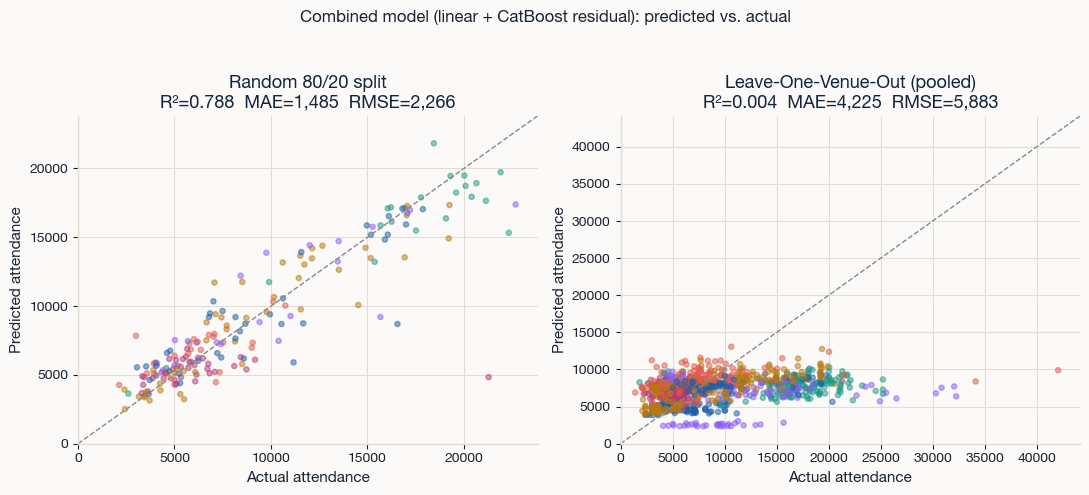

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
teams = sorted(reg_df["home_team"].unique())
team_color = {t: NWSL_PALETTE[i % len(NWSL_PALETTE)] for i, t in enumerate(teams)}

specs = [
    (axes[0], test_df["attendance"].values, np.exp(pred_split_log), test_df["home_team"].values, split_metrics, "Random 80/20 split"),
    (axes[1], np.exp(lovo_true), np.exp(lovo_pred), np.array(lovo_team), lovo_metrics, "Leave-One-Venue-Out (pooled)"),
]
for ax, y_true, y_pred, group_teams, m, title in specs:
    colors = pd.Series(group_teams).map(team_color)
    ax.scatter(y_true, y_pred, s=14, alpha=0.5, c=colors)
    lims = [0, max(y_true.max(), y_pred.max()) * 1.05]
    ax.plot(lims, lims, "--", color="#888888", linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual attendance"); ax.set_ylabel("Predicted attendance")
    ax.set_title(f"{title}\nR²={m['r2']:.3f}  MAE={m['mae']:,.0f}  RMSE={m['rmse']:,.0f}")
fig.suptitle("Combined model (linear + CatBoost residual): predicted vs. actual", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(os.path.join(OUTPUT_DIR, "catboost_combined_predicted_vs_actual.png"), dpi=150)
plt.show()

### Per-venue MAE
attendance variance can post a terrible R² on a small absolute error, same issue this project
found at the team level

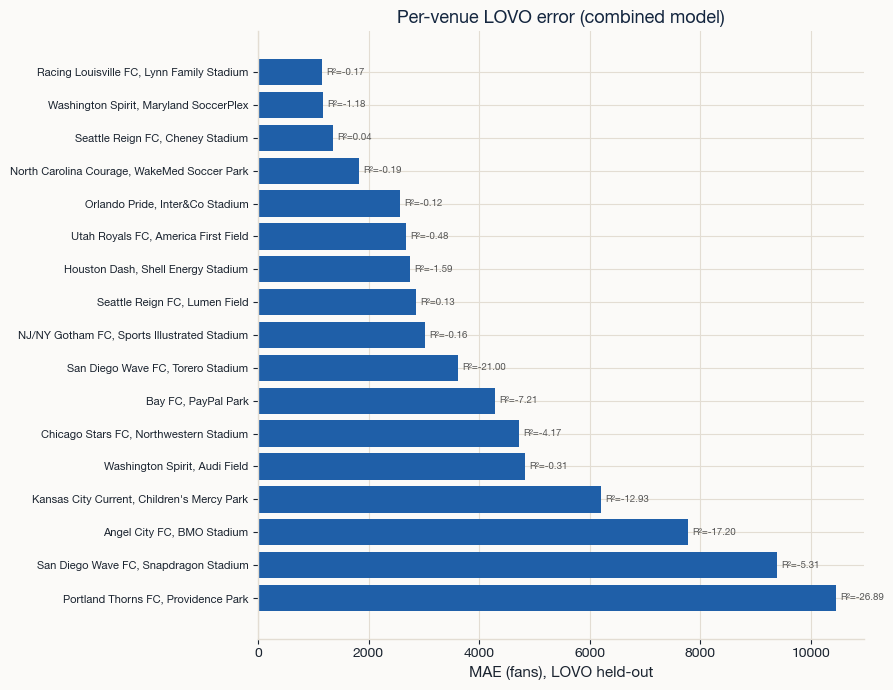

In [9]:
plot_df = lovo_df.sort_values("mae")
fig, ax = plt.subplots(figsize=(9, 7))
labels = plot_df["team"] + ", " + plot_df["venue_name"]
y_pos = np.arange(len(plot_df))
ax.barh(y_pos, plot_df["mae"], color=NWSL_PALETTE[0])
ax.set_yticks(y_pos, labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("MAE (fans), LOVO held-out")
ax.set_title("Per-venue LOVO error (combined model)")
for i, (mae, r2) in enumerate(zip(plot_df["mae"], plot_df["r2"])):
    ax.text(mae + 80, i, f"R²={r2:.2f}", va="center", fontsize=7, color="#555")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "catboost_lovo_per_venue_mae.png"), dpi=150)
plt.show()

### Debut-season overshoot, pooled across all 6 real relocations

Isolate each held-out venue's `team_venue_tenure == 0` rows (first season at that venue) within
the LOVO predictions above, pool across every relocating team.

In [10]:
lovo_full = pd.DataFrame({
    "team": lovo_team, "venue_name": lovo_venue, "team_venue_tenure": lovo_tenure,
    "true_log": lovo_true, "pred_log": lovo_pred,
})
debut = lovo_full[lovo_full["team_venue_tenure"] == 0]
debut_actual = np.exp(debut["true_log"]).sum()
debut_pred = np.exp(debut["pred_log"]).sum()
DEBUT_OVERSHOOT_RATIO = debut_pred / debut_actual if debut_actual > 0 else 1.0
print(f"{len(debut)} debut-season (tenure=0) games across {debut['team'].nunique()} teams' venue moves")
print(f"Actual total: {debut_actual:,.0f}  |  Predicted total: {debut_pred:,.0f}  |  "
      f"Overshoot ratio: {DEBUT_OVERSHOOT_RATIO:.3f}")
pd.DataFrame([{"n_debut_games": len(debut), "n_teams": debut["team"].nunique(),
               "overshoot_ratio": DEBUT_OVERSHOOT_RATIO}]).to_csv(
    os.path.join(OUTPUT_DIR, "catboost_debut_season_overshoot.csv"), index=False)

71 debut-season (tenure=0) games across 6 teams' venue moves
Actual total: 626,125  |  Predicted total: 536,942  |  Overshoot ratio: 0.858


## Final model: fit on all available data, for the Queens/Etihad Park counterfactual

In [11]:
final_lin = smf.ols("log_attendance ~ log_metro_size", data=reg_df).fit()  # matches 04's coefficient
final_cb = CatBoostRegressor(**CB_PARAMS, verbose=False)
final_cb.fit(reg_df[FEATURES], reg_df["residual"], cat_features=CAT_FEATURES)
final_cb.save_model(os.path.join(OUTPUT_DIR, "catboost_attendance_model.cbm"))

print("\nCatBoost residual-stage feature importance (metro_size is intentionally absent -- "
      "accessibility is handled entirely by the linear stage now, not 'unimportant'):")
imp = pd.Series(final_cb.get_feature_importance(), index=FEATURES).sort_values(ascending=False)
print(imp)
imp.to_csv(os.path.join(OUTPUT_DIR, "catboost_feature_importance.csv"))


CatBoost residual-stage feature importance (metro_size is intentionally absent -- accessibility is handled entirely by the linear stage now, not 'unimportant'):
venue_name                       26.604041
year                             10.059248
home_team                        10.014462
pct_commute_transit               7.000824
day_of_week                       6.719886
points_back_from_playoff_line     5.200204
team_league_tenure                4.979192
days_since_last_home_game         4.741831
away_team                         3.896910
stadium_capacity                  2.910433
stop_count_catchment              2.825643
precipitation_mm                  2.824522
ppg                               2.558748
temp_max_c                        2.278806
table_rank                        2.246287
team_venue_tenure                 1.939113
opponent_table_rank               1.630084
shared_with_other_league          1.322489
prior_sellout_rate                0.152136
dedicated_soccer_faci

## Queens counterfactual: Gotham FC at Etihad Park instead of Sports Illustrated Stadium

Etihad Park's real venue features. The linear stage extrapolates on `log(metro_size)` directly
(no capping, no dampening) -- that's the whole point of splitting the model this way, and the
log transform is what keeps that extrapolation defensible (see `linear_pred`'s docstring above).

In [12]:
catchment_pop = pd.read_csv(os.path.join(OUTPUT_DIR, "venue_catchment_population.csv")).set_index("stadium_id")
ETIHAD_METRO_SIZE = int(catchment_pop.loc["ETIHAD_PARK", "catchment_pop_60min"])
ETIHAD_LOG_METRO_SIZE = np.log(ETIHAD_METRO_SIZE)
ETIHAD_CAPACITY = 25000
ETIHAD_DEDICATED_SOCCER_FACILITY = 1
ETIHAD_SHARED_WITH_OTHER_LEAGUE = 1
train_max_metro = reg_df["metro_size"].max()
print(f"Training metro_size range: {reg_df['metro_size'].min():,.0f} - {train_max_metro:,.0f} "
      f"(log: {reg_df['log_metro_size'].min():.2f} - {reg_df['log_metro_size'].max():.2f})")
print(f"Etihad Park metro_size: {ETIHAD_METRO_SIZE:,.0f} (log: {ETIHAD_LOG_METRO_SIZE:.2f}) -- "
      f"{ETIHAD_METRO_SIZE / train_max_metro:.1f}x the training max in raw units, but only "
      f"{ETIHAD_LOG_METRO_SIZE - reg_df['log_metro_size'].max():.2f} log-units past it.")
print("The linear stage extrapolates this directly; CatBoost's residual stage never sees "
      "metro_size at all, so there's nothing for it to extrapolate.")

# ppg / points_back_from_playoff_line / prior_sellout_rate: Gotham's own most recent actual
# values (same most-recent-row convention as gotham_rank below) -- these describe the TEAM's
# form/history, not the venue, so they carry over unchanged from Sports Illustrated Stadium to
# Etihad Park.
gotham_sorted = df[df["home_team"] == "NJ/NY Gotham FC"].sort_values("date_time_utc")
ETIHAD_PPG = gotham_sorted["ppg"].iloc[-1]
ETIHAD_PLAYOFF_DIST = gotham_sorted["points_back_from_playoff_line"].iloc[-1]
ETIHAD_PRIOR_SELLOUT_RATE = gotham_sorted["prior_sellout_rate"].iloc[-1]
# temp_max_c / precipitation_mm: Etihad Park has no weather history of its own (not built yet) --
# Sports Illustrated Stadium is a few miles away in the same regional climate, so its historical
# median stands in as the best available proxy.
rba_weather = df[df["venue_name"] == "Sports Illustrated Stadium"]
ETIHAD_TEMP_MAX_C = rba_weather["temp_max_c"].median()
ETIHAD_PRECIPITATION_MM = rba_weather["precipitation_mm"].median()
# stop_count_catchment: genuinely unknown -- Etihad Park has no OSM/GTFS-derived stop count
# computed anywhere in this project (it isn't built yet), so this is left null rather than
# guessed. CatBoost handles missing values natively (splits on "missing" as its own branch), so
# this doesn't need to be dropped.
ETIHAD_STOP_COUNT_CATCHMENT = np.nan
# pct_commute_transit: Willets Point, Queens is in New York City proper (not Harrison, NJ, where
# Sports Illustrated Stadium sits) -- pulled directly for "New York city, New York" from the same
# ACS B08301 source as the other 14 venues (45.6% transit commute share, 1,801,669 / 3,954,938
# workers, 2023 5-year estimate), not reused from Sports Illustrated Stadium's very different
# host city.
ETIHAD_PCT_COMMUTE_TRANSIT = 1801669 / 3954938 * 100
ETIHAD_NEW_COLS = {
    "ppg": ETIHAD_PPG, "points_back_from_playoff_line": ETIHAD_PLAYOFF_DIST,
    "temp_max_c": ETIHAD_TEMP_MAX_C, "precipitation_mm": ETIHAD_PRECIPITATION_MM,
    "stop_count_catchment": ETIHAD_STOP_COUNT_CATCHMENT,
    "pct_commute_transit": ETIHAD_PCT_COMMUTE_TRANSIT,
    "prior_sellout_rate": ETIHAD_PRIOR_SELLOUT_RATE,
}
print(f"Etihad Park proxy values: {ETIHAD_NEW_COLS}")

pd.DataFrame([{
    "venue_name": "Etihad Park", "stadium_capacity": ETIHAD_CAPACITY,
    "metro_size": ETIHAD_METRO_SIZE,
    "dedicated_soccer_facility": ETIHAD_DEDICATED_SOCCER_FACILITY,
    "shared_with_other_league": ETIHAD_SHARED_WITH_OTHER_LEAGUE,
    **ETIHAD_NEW_COLS,
}]).to_csv(os.path.join(OUTPUT_DIR, "etihad_venue_features.csv"), index=False)

Training metro_size range: 6,028 - 1,464,640 (log: 8.70 - 14.20)
Etihad Park metro_size: 3,201,230 (log: 14.98) -- 2.2x the training max in raw units, but only 0.78 log-units past it.
The linear stage extrapolates this directly; CatBoost's residual stage never sees metro_size at all, so there's nothing for it to extrapolate.
Etihad Park proxy values: {'ppg': np.float64(2.0), 'points_back_from_playoff_line': np.int64(-10), 'temp_max_c': 24.2, 'precipitation_mm': 0.1, 'stop_count_catchment': nan, 'pct_commute_transit': 45.554923996280095, 'prior_sellout_rate': np.float64(0.0)}


In [13]:
opponents = sorted(df["away_team"].unique())
opponents = [o for o in opponents if o != "NJ/NY Gotham FC"]
day_options = ["Friday", "Saturday", "Sunday"]
gotham_rank = df[df["home_team"] == "NJ/NY Gotham FC"].sort_values("date_time_utc")["table_rank"].iloc[-1]
opp_rank_lookup = (
    df[df["away_team"].isin(opponents)].sort_values("date_time_utc").groupby("away_team")["opponent_table_rank"].last()
)
median_days_since = df["days_since_last_home_game"].median()

base_cols = ["table_rank", "opponent_table_rank", "days_since_last_home_game", "year",
             "day_of_week", "home_team", "away_team"]
# team_league_tenure: Gotham (formerly Sky Blue FC) is a 2013 founding-era team -- see 09's
# FOUNDING_YEAR_OVERRIDE -- so this is a real, in-range value now (13, matching the training
# panel's own observed max for this team), not the NaN it had to be before that fix.
GOTHAM_LEAGUE_TENURE_2026 = 2026 - 2013
rows = []
for opp in opponents:
    for day in day_options:
        rows.append({
            "table_rank": gotham_rank,
            "opponent_table_rank": opp_rank_lookup.get(opp, df["opponent_table_rank"].median()),
            "days_since_last_home_game": median_days_since, "year": 2026,
            "day_of_week": day, "venue_name": "Etihad Park", "home_team": "NJ/NY Gotham FC",
            "away_team": opp, "stadium_capacity": ETIHAD_CAPACITY,
            "metro_size": ETIHAD_METRO_SIZE, "log_metro_size": ETIHAD_LOG_METRO_SIZE,
            "dedicated_soccer_facility": ETIHAD_DEDICATED_SOCCER_FACILITY,
            "shared_with_other_league": ETIHAD_SHARED_WITH_OTHER_LEAGUE,
            "team_venue_tenure": 0, "team_league_tenure": GOTHAM_LEAGUE_TENURE_2026,
            **ETIHAD_NEW_COLS,
        })
synthetic = pd.DataFrame(rows)
for c in CAT_FEATURES:
    synthetic[c] = synthetic[c].astype(str)
synthetic[base_cols].to_csv(os.path.join(OUTPUT_DIR, "gotham_synthetic_grid_base.csv"), index=False)
print(f"{len(synthetic)} synthetic games ({len(opponents)} opponents x {len(day_options)} days)")

54 synthetic games (18 opponents x 3 days)


In [14]:
synthetic["linear_component"] = linear_pred(synthetic["log_metro_size"])
synthetic["linear_component_ci_low"] = linear_pred(synthetic["log_metro_size"], LINEAR_COEF_CI_LOW)
synthetic["linear_component_ci_high"] = linear_pred(synthetic["log_metro_size"], LINEAR_COEF_CI_HIGH)
synthetic["residual_component"] = final_cb.predict(synthetic[FEATURES])

synthetic["pred_log_attendance"] = synthetic["linear_component"] + synthetic["residual_component"]
synthetic["pred_attendance"] = np.clip(np.exp(synthetic["pred_log_attendance"]), None, ETIHAD_CAPACITY)
synthetic["pred_attendance_ci_low"] = np.clip(
    np.exp(synthetic["linear_component_ci_low"] + synthetic["residual_component"]), None, ETIHAD_CAPACITY)
synthetic["pred_attendance_ci_high"] = np.clip(
    np.exp(synthetic["linear_component_ci_high"] + synthetic["residual_component"]), None, ETIHAD_CAPACITY)
synthetic["pred_attendance_debut_adjusted"] = np.clip(
    synthetic["pred_attendance"] / DEBUT_OVERSHOOT_RATIO, None, ETIHAD_CAPACITY)

synthetic.to_csv(os.path.join(OUTPUT_DIR, "queens_counterfactual_predictions.csv"), index=False)

print("=== Summary: predicted Gotham/Etihad Park attendance (combined model) ===")
print(synthetic["pred_attendance"].describe())

=== Summary: predicted Gotham/Etihad Park attendance (combined model) ===
count       54.000000
mean     12367.909414
std       1263.128195
min       9996.873098
25%      11106.338335
50%      12733.220503
75%      13346.832476
max      14822.008940
Name: pred_attendance, dtype: float64


In [15]:
range_summary = pd.DataFrame([{
    "metro_size": ETIHAD_METRO_SIZE,
    "linear_component_mean": synthetic["linear_component"].mean(),
    "residual_component_mean": synthetic["residual_component"].mean(),
    "combined_point_mean": synthetic["pred_attendance"].mean(),
    "combined_ci_low_mean": synthetic["pred_attendance_ci_low"].mean(),
    "combined_ci_high_mean": synthetic["pred_attendance_ci_high"].mean(),
    "debut_overshoot_ratio": DEBUT_OVERSHOOT_RATIO,
    "debut_adjusted_point_mean": synthetic["pred_attendance_debut_adjusted"].mean(),
    "sellout_fraction": (synthetic["pred_attendance"] >= ETIHAD_CAPACITY).mean(),
}])
range_summary.to_csv(os.path.join(OUTPUT_DIR, "queens_counterfactual_range_summary.csv"), index=False)
print(range_summary.to_string(index=False))

 metro_size  linear_component_mean  residual_component_mean  combined_point_mean  combined_ci_low_mean  combined_ci_high_mean  debut_overshoot_ratio  debut_adjusted_point_mean  sellout_fraction
    3201230               9.413153                 0.004404         12367.909414           1001.805305                25000.0               0.857564               14422.139058               0.0


## `queens_attendance_by_model.csv` 

In [16]:
old_queens_by_model = pd.read_csv(os.path.join(OUTPUT_DIR, "queens_attendance_by_model.csv"))
old_queens_by_model["catboost_full_naive"] = range_summary["combined_point_mean"].iloc[0]
old_queens_by_model["catboost_full_honest"] = range_summary["debut_adjusted_point_mean"].iloc[0]
old_queens_by_model.to_csv(os.path.join(OUTPUT_DIR, "queens_attendance_by_model.csv"), index=False)
print(old_queens_by_model.to_string(index=False))
print("\nNote: 'naive' here = combined-model point estimate before the debut-season correction; "
      "'honest' = after it. linear_*/gbt_* columns are historical (old 04 models, deleted this "
      "session) -- kept only so QueensPredictionTable.tsx doesn't break; that component's data "
      "shape will need a follow-up update, not done in this pass.")

 linear_baseline_naive  linear_extended_naive  linear_extended_honest  gbt_extended_naive  gbt_extended_honest  catboost_full_naive  catboost_full_honest
           11199.88466           44889.823259           105688.490357         11733.29533         12078.239977         12367.909414          14422.139058

Note: 'naive' here = combined-model point estimate before the debut-season correction; 'honest' = after it. linear_*/gbt_* columns are historical (old 04 models, deleted this session) -- kept only so QueensPredictionTable.tsx doesn't break; that component's data shape will need a follow-up update, not done in this pass.
